In [1]:
import pandas as pd
from SCPIntModel import *

In [2]:
import scanpy as sc

In [3]:
multibatch_ann = sc.read_h5ad('../data/task_data/multi_batch_task_four_sets_ann.h5ad')

In [4]:
multibatch_ann

AnnData object with n_obs × n_vars = 1937 × 554
    obs: 'celltype', 'batch'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [5]:
processor = AnnDataProcessor(multibatch_ann, batch_key="batch")

Loaded 1937 cells × 554 proteins
Batches (4): ['derks', 'leduc2021', 'leduc2023', 'specht']


In [6]:
loader  = processor.make_dataloader(batch_size=128)

In [7]:
 # 构建模型
model = scProteoIntegrator(
    n_genes   = processor.n_genes,
    n_batches = processor.n_batches,
)

In [8]:
lambda_cls=0.1
lambda_adv=0.3
lambda_mse=0.5
lr = 0.01
epochs = 1000
warmup = 1
md = 'multibatch'

In [9]:
trainer = Trainer(model, lr=lr, lambda_cls=lambda_cls, lambda_adv=lambda_adv,lambda_mse=lambda_mse, lr_reduc_factor=0.9)

In [10]:
trainer.fit(loader, n_epochs=epochs, adv_warmup_epochs=warmup)

Epoch   10 | total=2.6964 | recon=1.3528 | mse=0.8904 | cls=0.3425 | adv=2.8802 |lr=0.009000000000000001
Epoch   20 | total=11.7842 | recon=1.3788 | mse=0.9259 | cls=0.3437 | adv=33.0268 |lr=0.008100000000000001
Epoch   30 | total=6.4609 | recon=1.3616 | mse=0.9067 | cls=0.2187 | adv=15.4139 |lr=0.006561000000000002
Epoch   40 | total=2.9290 | recon=1.3518 | mse=0.8932 | cls=0.1571 | adv=3.7163 |lr=0.005904900000000002
Epoch   50 | total=2.4290 | recon=1.3349 | mse=0.8710 | cls=0.1080 | adv=2.1594 |lr=0.004782969000000002
Epoch   60 | total=2.1493 | recon=1.3249 | mse=0.8575 | cls=0.0266 | adv=1.3101 |lr=0.004304672100000002
Epoch   70 | total=1.9663 | recon=1.3114 | mse=0.8414 | cls=0.1538 | adv=0.7295 |lr=0.003874204890000002
Epoch   80 | total=1.9173 | recon=1.2867 | mse=0.8175 | cls=0.0024 | adv=0.7389 |lr=0.003874204890000002
Epoch   90 | total=1.8938 | recon=1.2579 | mse=0.7914 | cls=0.0302 | adv=0.7905 |lr=0.003486784401000002
Epoch  100 | total=1.9306 | recon=1.2551 | mse=0.790

In [11]:
model_name = f"{md}_cls-{lambda_cls}_adv-{lambda_adv}_mse-{lambda_mse}_warmup-{warmup}_lr-{lr}_epoch-{epochs}"

损失曲线已保存至: ../data/model/multibatch_cls-0.1_adv-0.3_mse-0.5_warmup-1_lr-0.01_epoch-1000.svg


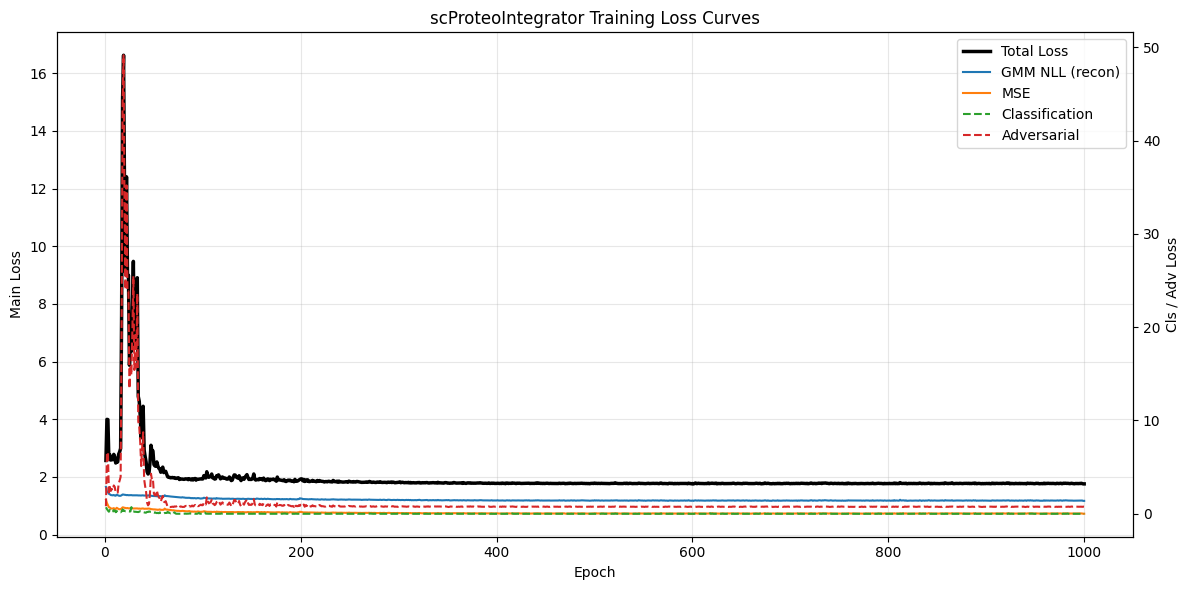

In [12]:
trainer.plot_losses(
    save_path=f"../data/model/{model_name}.svg",   # 可改成任意路径
    show=True                      # False 则只保存不弹窗
)

In [13]:
trainer.save(f"../data/model/{model_name}.pt")

Model saved to ../data/model/multibatch_cls-0.1_adv-0.3_mse-0.5_warmup-1_lr-0.01_epoch-1000.pt
